In [1]:
!pip install numpy pandas pillow torch torchvision scikit-learn matplotlib

In [2]:
# =========================================================
# FEDERATED LEARNING – FedAvg with EfficientNet-B0
# Same data, same personalisation (0-1 scale)
# Single GPU, 5 clients (demographic groups)
# =========================================================
import os, random, numpy as np, pandas as pd, copy
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [3]:
# =========================================================
# CONFIGURATION
# =========================================================
CSV_PATH = "/kaggle/input/datasets/rahulsonboro/ui-aestheticdataset/Aes_dataset - Sheet1.csv"
DESKTOP_IMG_DIR = "/kaggle/input/datasets/rahulsonboro/ui-aestheticdataset/images/desktop img"
MOBILE_IMG_DIR   = "/kaggle/input/datasets/rahulsonboro/ui-aestheticdataset/images/mobile img"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ---------- Hyperparameters ----------
BATCH_SIZE = 16
NUM_WORKERS = 2
LEARNING_RATE = 1e-4
LOCAL_EPOCHS = 1              # per client per round
NUM_ROUNDS = 50               # communication rounds
PATIENCE = 10                 # for early stopping (rounds)
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

USE_PRETRAINED = True
torch.cuda.empty_cache()

# =========================================================
# DATA LOADING & CLEANING (identical to before)
# =========================================================
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
before = len(df)
df.dropna(inplace=True)
print(f"Dropped {before - len(df)} rows")

Device: cuda
Dropped 0 rows


Global Mean Rating: 6.0613
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 179MB/s]



Clients: ['female_nonworking', 'female_student', 'female_working', 'male_student', 'male_working']
Total clients: 5

Starting Federated Training (50 rounds, local epochs=1)...

Round   1 | Val MSE: 0.0702 | female_nonworking: 0.0394 | female_student: 0.0736 | female_working: 0.1035 | male_student: 0.0671 | male_working: 0.1047
Round   2 | Val MSE: 0.0643 | female_nonworking: 0.0267 | female_student: 0.0707 | female_working: 0.0956 | male_student: 0.0618 | male_working: 0.0885
Round   3 | Val MSE: 0.0642 | female_nonworking: 0.0257 | female_student: 0.0686 | female_working: 0.0876 | male_student: 0.0644 | male_working: 0.0841
Round   4 | Val MSE: 0.0617 | female_nonworking: 0.0233 | female_student: 0.0633 | female_working: 0.0938 | male_student: 0.0630 | male_working: 0.0834
Round   5 | Val MSE: 0.0583 | female_nonworking: 0.0222 | female_student: 0.0599 | female_working: 0.0934 | male_student: 0.0581 | male_working: 0.0874
Round   6 | Val MSE: 0.0566 | female_nonworking: 0.0183 | fema

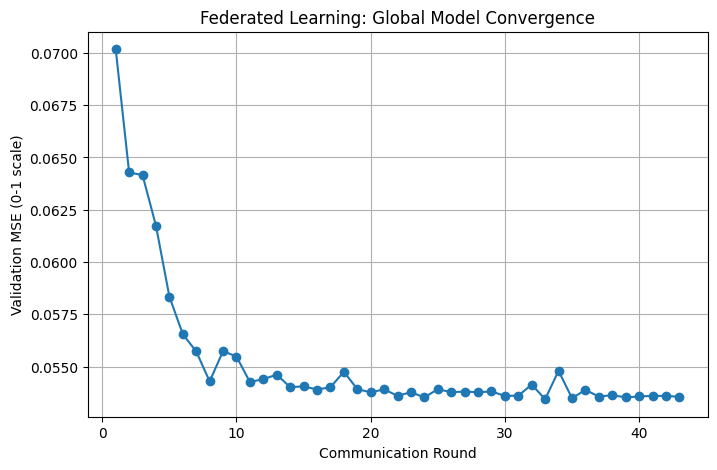

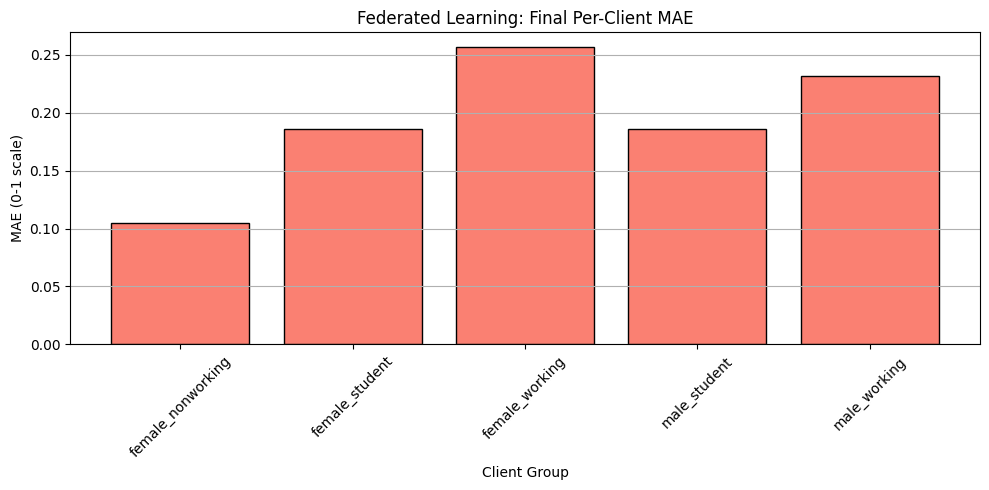

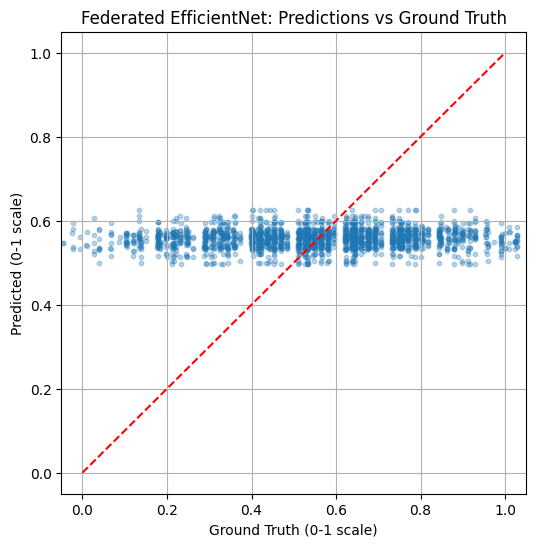

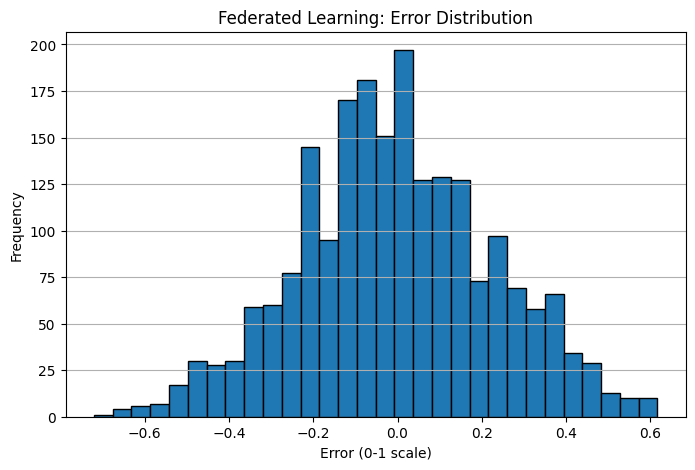

In [4]:
# User means (using all data for consistency with earlier runs)
user_means = {}
for uid, group in df.groupby('user_id'):
    all_ratings = pd.concat([group['desktop_rating'], group['mobile_rating']])
    user_means[uid] = all_ratings.mean()

GLOBAL_MEAN = pd.concat([df['desktop_rating'], df['mobile_rating']]).mean()
print(f"Global Mean Rating: {GLOBAL_MEAN:.4f}")

# Client grouping (demographic groups)
def get_client_id(gender, qualification):
    gender_str = 'male' if gender == 0 else 'female'
    qual_map = {0: 'nonworking', 1: 'student', 2: 'working'}
    return f"{gender_str}_{qual_map[qualification]}"

user_client_map = {}
for _, row in df.iterrows():
    uid = row['user_id']
    if uid not in user_client_map:
        user_client_map[uid] = get_client_id(row['gender'], row['qualification'])

client_counts = {}
for uid, cid in user_client_map.items():
    client_counts[cid] = client_counts.get(cid, 0) + 1

# Train/val split per client
client_train_users, client_val_users = {}, {}
for cid in client_counts:
    users = [uid for uid, c in user_client_map.items() if c == cid]
    train_uids, val_uids = train_test_split(users, test_size=0.2, random_state=SEED)
    client_train_users[cid] = train_uids
    client_val_users[cid] = val_uids

# Create train/val DataFrames per client
client_train_dfs = {}
client_val_dfs = {}
for cid in client_counts:
    client_train_dfs[cid] = df[df['user_id'].isin(client_train_users[cid])].copy()
    client_val_dfs[cid]   = df[df['user_id'].isin(client_val_users[cid])].copy()

# =========================================================
# TRANSFORMS (same as before)
# =========================================================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# =========================================================
# DATASET (personalised + 0-1 scaling) – same class
# =========================================================
class PersonalizedDataset(Dataset):
    def __init__(self, dataframe, desktop_dir, mobile_dir, user_means, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.desktop_dir = desktop_dir
        self.mobile_dir = mobile_dir
        self.user_means = user_means
        self.transform = transform
        self.global_mean = GLOBAL_MEAN

    def __len__(self):
        return len(self.df) * 2

    def __getitem__(self, idx):
        row_idx = idx // 2
        is_mobile = idx % 2
        row = self.df.iloc[row_idx]
        image_no = int(row['image_no'])
        uid = row['user_id']

        if is_mobile:
            img_path = os.path.join(self.mobile_dir, f"mob_{image_no}.png")
            raw_rating = float(row['mobile_rating'])
        else:
            img_path = os.path.join(self.desktop_dir, f"des_{image_no}.png")
            raw_rating = float(row['desktop_rating'])

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        centered = raw_rating - self.user_means[uid] + self.global_mean
        normalized = (centered - 1.0) / 9.0
        return image, torch.tensor(normalized, dtype=torch.float32)

# =========================================================
# CLIENT LOADERS
# =========================================================
def get_client_loaders(cid):
    train_df = client_train_dfs[cid]
    val_df   = client_val_dfs[cid]

    train_ds = PersonalizedDataset(train_df, DESKTOP_IMG_DIR, MOBILE_IMG_DIR, user_means, train_transform)
    val_ds   = PersonalizedDataset(val_df,   DESKTOP_IMG_DIR, MOBILE_IMG_DIR, user_means, val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)
    return train_loader, val_loader, len(train_ds)

# =========================================================
# MODEL (same EfficientNet-B0)
# =========================================================
class EfficientNetRegressor(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        if pretrained:
            self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        else:
            self.backbone = models.efficientnet_b0(weights=None)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.backbone(x).squeeze(1)

# =========================================================
# FEDAVG FUNCTIONS
# =========================================================

def local_train(model, train_loader, optimizer, scaler, epochs=1):
    """Train locally for a few epochs, return updated state_dict."""
    model.train()
    for _ in range(epochs):
        for images, ratings in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            ratings = ratings.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            if scaler is not None:
                with autocast('cuda'):
                    preds = model(images)
                    loss = nn.MSELoss()(preds, ratings)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                preds = model(images)
                loss = nn.MSELoss()(preds, ratings)
                loss.backward()
                optimizer.step()
    return model.state_dict()

def fedavg_aggregate(global_state, client_states, client_weights):
    """Weighted average of state_dicts (FedAvg)."""
    avg_state = {}
    total_weight = sum(client_weights)
    for key in global_state.keys():
        avg_state[key] = sum(client_states[i][key] * client_weights[i] for i in range(len(client_states))) / total_weight
    return avg_state

def evaluate_global(model, client_ids):
    """Evaluate global model on all clients' validation sets."""
    model.eval()
    total_loss, total_samples = 0.0, 0
    all_preds, all_targets = [], []
    client_metrics = {}
    with torch.no_grad():
        for cid in client_ids:
            _, val_loader, _ = get_client_loaders(cid)
            client_loss, client_samples = 0.0, 0
            for images, ratings in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                ratings = ratings.to(DEVICE, non_blocking=True)
                with autocast('cuda'):
                    preds = model(images)
                    loss = nn.MSELoss()(preds, ratings)
                client_loss += loss.item() * images.size(0)
                client_samples += images.size(0)
                all_preds.extend(preds.float().cpu().numpy())
                all_targets.extend(ratings.cpu().numpy())
            client_metrics[cid] = client_loss / client_samples
            total_loss += client_loss
            total_samples += client_samples
    overall_mse = total_loss / total_samples
    return overall_mse, client_metrics, all_preds, all_targets

# =========================================================
# INITIALISE GLOBAL MODEL
# =========================================================
global_model = EfficientNetRegressor(pretrained=USE_PRETRAINED).to(DEVICE)
global_state = copy.deepcopy(global_model.state_dict())
scaler = GradScaler('cuda') if DEVICE.type == 'cuda' else None

client_ids = sorted(client_counts.keys())
print("\nClients:", client_ids)
print(f"Total clients: {len(client_ids)}")

# =========================================================
# TRAINING LOOP (FEDAVG)
# =========================================================
round_losses = []
best_loss = float('inf')
patience_counter = 0
round_mae_per_client = {cid: [] for cid in client_ids}   # for tracking

print(f"\nStarting Federated Training ({NUM_ROUNDS} rounds, local epochs={LOCAL_EPOCHS})...\n")

for round_idx in range(1, NUM_ROUNDS+1):
    client_states = []
    client_weights = []

    # 1. Local training on each client
    for cid in client_ids:
        train_loader, _, num_samples = get_client_loaders(cid)
        # Clone global model
        local_model = EfficientNetRegressor(pretrained=USE_PRETRAINED).to(DEVICE)
        local_model.load_state_dict(global_state)
        optimizer = optim.AdamW(local_model.parameters(), lr=LEARNING_RATE)

        updated_state = local_train(local_model, train_loader, optimizer, scaler, epochs=LOCAL_EPOCHS)
        client_states.append(updated_state)
        client_weights.append(num_samples)

    # 2. Aggregate (FedAvg)
    global_state = fedavg_aggregate(global_state, client_states, client_weights)
    global_model.load_state_dict(global_state)

    # 3. Evaluate
    val_loss, client_metrics, _, _ = evaluate_global(global_model, client_ids)
    round_losses.append(val_loss)

    # per-client MAE (on 0-1 scale)
    for cid in client_ids:
        round_mae_per_client[cid].append(np.sqrt(client_metrics[cid]))   # using RMSE as proxy, or compute actual MAE below
    # For MAE specifically, we'll compute it later in final plots; here we just store the loss (MSE).

    print(f"Round {round_idx:3d} | Val MSE: {val_loss:.4f}", end='')
    for cid in client_ids:
        print(f" | {cid}: {client_metrics[cid]:.4f}", end='')
    print()

    # Early stopping based on val_loss
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(global_state, "best_federated_model.pth")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

# Load best model
global_model.load_state_dict(torch.load("best_federated_model.pth"))

# =========================================================
# FINAL EVALUATION (collect predictions for plots)
# =========================================================
val_loss, client_metrics, all_preds, all_targets = evaluate_global(global_model, client_ids)
mse = mean_squared_error(all_targets, all_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_targets, all_preds)

print("\nFinal Federated Results (0-1 scale)")
print("-" * 40)
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

# =========================================================
# PLOTTING
# =========================================================

# 1. Validation loss over rounds
plt.figure(figsize=(8,5))
plt.plot(range(1, len(round_losses)+1), round_losses, marker='o')
plt.xlabel('Communication Round')
plt.ylabel('Validation MSE (0-1 scale)')
plt.title('Federated Learning: Global Model Convergence')
plt.grid(True)
plt.savefig('fed_convergence.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Per-client MAE over rounds (MAE computed explicitly)
# Re-compute per-client MAE for each round we stored MSE; we'll compute from metrics now.
# We already stored client_metrics (MSE) per round; we'll convert to RMSE for display.
# Actually we want MAE on 0-1 scale. We'll re-evaluate after training to get per-client MAE correctly.
# Let's compute after the loop using the best model.
final_client_mae = {}
for cid in client_ids:
    _, val_loader, _ = get_client_loaders(cid)
    total_l1, count = 0.0, 0
    with torch.no_grad():
        for images, ratings in val_loader:
            images = images.to(DEVICE)
            ratings = ratings.to(DEVICE)
            preds = global_model(images)
            total_l1 += torch.sum(torch.abs(preds - ratings)).item()
            count += images.size(0)
    final_client_mae[cid] = total_l1 / count

sorted_clients = sorted(final_client_mae.keys())
mae_vals = [final_client_mae[c] for c in sorted_clients]

plt.figure(figsize=(10,5))
plt.bar(sorted_clients, mae_vals, color='salmon', edgecolor='black')
plt.xticks(rotation=45)
plt.xlabel('Client Group')
plt.ylabel('MAE (0-1 scale)')
plt.title('Federated Learning: Final Per-Client MAE')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('fed_client_mae.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Scatter: Predicted vs Ground Truth (0-1 scale)
plt.figure(figsize=(6,6))
plt.scatter(all_targets, all_preds, alpha=0.3, s=10)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('Ground Truth (0-1 scale)')
plt.ylabel('Predicted (0-1 scale)')
plt.title('Federated EfficientNet: Predictions vs Ground Truth')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.savefig('fed_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Error histogram (0-1 scale)
errors = np.array(all_preds) - np.array(all_targets)
plt.figure(figsize=(8,5))
plt.hist(errors, bins=30, edgecolor='black')
plt.xlabel('Error (0-1 scale)')
plt.ylabel('Frequency')
plt.title('Federated Learning: Error Distribution')
plt.grid(axis='y')
plt.savefig('fed_error_hist.png', dpi=300, bbox_inches='tight')
plt.show()